<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>

# Introdução: O que é Aprendizado Ensemble?

Suponha que você faça uma pergunta complexa para milhares de pessoas aleatórias e depois agrupe as respostas. Em muitos casos, você descobrirá que essa resposta agregada é melhor que a resposta de um único especialista. Isso é conhecido como a **sabedoria das multidões**.

Nesse contexto, ao agregar as previsões de um grupo de preditores (classificadores ou regressores), você obterá previsões melhores do que com o melhor preditor individual.
* Um grupo de preditores é chamado de **ensemble** (agrupamento).
* A técnica se chama **aprendizado ensemble**.
* O algoritmo resultante é chamado de **método ensemble**.

### Por que o Ensemble funciona?
Modelos individuais de machine learning geralmente sofrem de um de dois problemas principais:

1. **Viés alto (Underfitting):** O modelo é muito simples e não consegue capturar o padrão dos dados.

2. **Variância alta (Overfitting):** O modelo é muito complexo e decora os dados de treino, falhando ao generalizar.

O aprendizado ensemble funciona pois a combinação matemática de vários modelos ajuda a mitigar o viés e a variância simultaneamente.

In [ ]:
# 1. Bibliotecas Base e Utilitários
import numpy as np
import time
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_predict, cross_validate

# 2. Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import PredictionErrorDisplay

# 3. Datasets
from sklearn.datasets import make_moons, fetch_openml

# 4. Pré-processamento e Pipelines
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# 5. Modelos de Base (Classificadores e Regressores)
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# 6. Modelos Ensemble (Bagging, Boosting e Stacking)
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    VotingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor
)

# 7. Métricas
from sklearn.metrics import accuracy_score, r2_score

# 1. Classificadores de Votação (Voting Classifiers)

Uma das formas mais simples de criar um ensemble é treinar vários classificadores independentes (ex: Regressão Logística, Random Forest, SVM) nos mesmos dados e combiná-los:

* **Hard Voting:** A classe final predita é a que recebe a maioria dos votos dos classificadores.

* **Soft Voting:** Se todos os classificadores puderem estimar probabilidades (`predict_proba`), a classe predita é a que possui a maior probabilidade média. Geralmente resulta em melhor performance.

In [ ]:
# Gerando dados não lineares
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

print("features: \n", X[:5])
print("target: \n", y[:5])

features: 
 [[ 0.83103915 -0.25874875]
 [ 1.18506381  0.92038714]
 [ 1.16402213 -0.45552558]
 [-0.0236556   1.08628844]
 [ 0.48050273  1.50942444]]
target: 
 [1 0 1 0 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Configurando o Hard Voting
voting_clf_hard = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('lr', LogisticRegression(random_state=42)),
        ('svc', SVC(random_state=42))
    ],
    voting='hard'
)

In [ ]:
voting_clf_hard.fit(X_train, y_train)

print("\n--- Acurácia (Hard Voting) ---")
for name, clf in voting_clf_hard.named_estimators_.items():
    print(f"{name} = {clf.score(X_test, y_test):.4f}")
print(f"Voting (Hard) = {voting_clf_hard.score(X_test, y_test):.4f}")


--- Acurácia (Hard Voting) ---
rf = 0.8960
lr = 0.8640
svc = 0.8960
Voting (Hard) = 0.9120


In [ ]:
# Predição do Classificador de Votação
voting_clf_hard.predict(X_test[:1])

array([1])

In [ ]:
voting_clf_hard.estimators_

[RandomForestClassifier(random_state=42),
 LogisticRegression(random_state=42),
 SVC(random_state=42)]

In [ ]:
# Predições de cada modelo
[clf.predict(X_test[:1]) for clf in voting_clf_hard.estimators_]

[array([1]), array([1]), array([0])]

In [ ]:
# Configurando o Soft Voting (Exige probabilidade no SVC)
voting_clf_soft = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('lr', LogisticRegression(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)

In [ ]:
voting_clf_soft.fit(X_train, y_train)

print("\n--- Acurácia (Soft Voting) ---")
for name, clf in voting_clf_soft.named_estimators_.items():
    print(f"{name} = {clf.score(X_test, y_test):.4f}")
print(f"Voting (Soft) = {voting_clf_soft.score(X_test, y_test):.4f}")


--- Acurácia (Soft Voting) ---
rf = 0.8960
lr = 0.8640
svc = 0.8960
Voting (Soft) = 0.9200


In [ ]:
# Predição do Classificador de Votação
voting_clf_soft.predict(X_test[:1])

array([0])

In [ ]:
# Predições de cada modelo
[clf.predict(X_test[:1]) for clf in voting_clf_soft.estimators_]

[array([1]), array([1]), array([0])]

In [ ]:
# Predições de cada modelo
probabilidades = np.array([clf.predict_proba(X_test[:1]) for clf in voting_clf_soft.estimators_])
probabilidades

array([[[0.48      , 0.52      ]],

       [[0.49900001, 0.50099999]],

       [[0.56982947, 0.43017053]]])

In [ ]:
probabilidades[:,0,0].mean()

np.float64(0.5162764924846871)

In [ ]:
probabilidades[:,0,1].mean()

np.float64(0.48372350751531296)

# 2. Bagging e Pasting

Outra abordagem é usar o **mesmo algoritmo de treinamento** para cada preditor, mas treiná-los em **subconjuntos aleatórios diferentes** do conjunto de treinamento.

* **Bagging (Bootstrap Aggregating):** A amostragem é realizada **com reposição**.

* **Pasting:** A amostragem é realizada **sem reposição**.

Depois que todos os preditores são treinados, o conjunto faz previsões para novas instâncias agregando as previsões de todos os preditores. A agregação reduz tanto o viés quanto a variância, resultando num modelo que generaliza melhor e tem uma fronteira de decisão mais suave.

Um `BaggingClassifier` realiza automaticamente soft voting se o classificador base puder estimar probabilidades de classe (ex: árvores de decisão).

In [ ]:
# Para alterar para Pasting, basta usar bootstrap=False
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, n_jobs=-1, random_state=42
)

bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print(f"Acurácia Árvore Única: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Acurácia Bagging (500 árvores): {accuracy_score(y_test, y_pred_bag):.4f}")

Acurácia Árvore Única: 0.8560
Acurácia Bagging (500 árvores): 0.9040


Compara a fronteira de decisão de uma **única árvore de decisão** com a fronteira de decisão de um conjunto de **bagging de 500 árvores**, ambos treinados no conjunto de dados "moons".

Como você pode ver, as previsões do conjunto provavelmente terão uma generalização muito melhor do que as previsões da única árvore de decisão: o conjunto tem um viés comparável, mas uma variância menor (faz aproximadamente o mesmo número de erros no conjunto de treinamento, mas a fronteira de decisão é menos irregular).

In [ ]:
def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.5, -1, 1.5], alpha=0.5, contour=True, line_color=None):
    x1s = np.linspace(axes[0], axes[1], 300)
    x2s = np.linspace(axes[2], axes[3], 300)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    # 1. Cores de fundo com maior contraste (Amarelo Ouro e Azul Royal Suave)
    custom_cmap = ListedColormap(['#FFD700', '#4169E1'])
    plt.contourf(x1, x2, y_pred, alpha=0.2, cmap=custom_cmap)

    if contour:
        # 2. Se line_color for fornecido, usa para a linha da fronteira
        # Caso contrário, usa um padrão cinza escuro
        if line_color:
            plt.contour(x1, x2, y_pred, colors=[line_color], alpha=0.8, linewidths=2)
        else:
            plt.contour(x1, x2, y_pred, colors=['#444444'], alpha=0.5, linewidths=1)

    # Plotagem dos pontos com borda preta para melhor visibilidade
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha, markeredgecolor='k', label="Classe 0")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha, markeredgecolor='k', label="Classe 1")
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

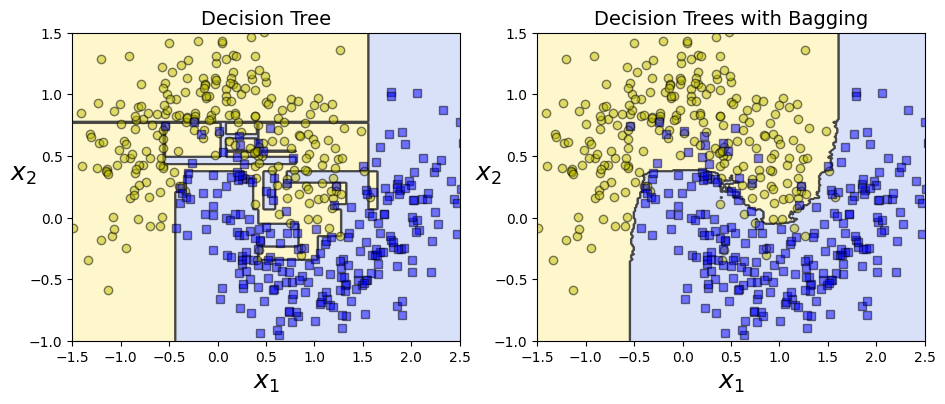

In [ ]:
plt.figure(figsize=(11,4))
plt.subplot(121)
plot_decision_boundary(tree_clf, X, y)
plt.title("Decision Tree", fontsize=14)
plt.subplot(122)
plot_decision_boundary(bag_clf, X, y)
plt.title("Decision Trees with Bagging", fontsize=14)
plt.show()

## 2.1 Avaliação Out-of-Bag (OOB)

A avaliação **Out-of-Bag (OOB)** é um dos recursos mais poderosos do Bagging, pois permite testar o desempenho do modelo "de graça", sem precisar sacrificar dados para um conjunto de validação separado.

### 2.1.1 Por que apenas 63%?
No Bagging, quando criamos um subconjunto de treino para cada preditor, usamos **amostragem com reposição** (*bootstrap*). Imagine uma urna com $n$ bolas numeradas. Você tira uma bola, anota o número e a devolve para a urna antes de tirar a próxima. Você repete isso $n$ vezes.

Matematicamente, a probabilidade de uma instância específica *não* ser escolhida em $n$ sorteios (quando $n$ é grande) converge para $1/e$, que é aproximadamente **36,8%**.

* **Instâncias In-Bag (Selecionadas):** Em média, 63,2% das instâncias são usadas no treino de cada modelo.

* **Instâncias Out-of-Bag (OOB):** Os 36,8% restantes que "ficaram de fora" para aquele preditor específico.

### 2.1.2 Como funciona o Score OOB?
Como o conjunto OOB é **diferente para cada modelo**, o Scikit-Learn utiliza essa sobra de forma inteligente:
    
1.  Para cada instância do dataset original, o algoritmo identifica quais modelos **não** a utilizaram durante o treinamento.

2.  Ele solicita que apenas esses modelos façam uma previsão para aquela instância.

3.  As previsões são agregadas (votação ou média), gerando uma previsão "limpa" (feita por modelos que nunca viram aquele dado).

4.  O **Score OOB** é a média dessas previsões comparadas aos valores reais.



### 2.1.3 Vantagens Pedagógicas e Práticas
* **Economia de Dados:** Ideal para datasets pequenos, pois permite usar 100% dos dados para treino e ainda assim ter uma validação confiável.
* **Estimativa Realista:** O score OOB costuma ser uma estimativa muito próxima (e às vezes mais rigorosa) do que o modelo encontrará no conjunto de teste real.
* **Prevenção de Overfitting:** Como a avaliação é feita apenas por modelos que não "decoraram" aquela instância, o resultado é um teste de generalização genuíno.

No Scikit-Learn, basta definir `oob_score=True` ao criar o `BaggingClassifier` para solicitar essa avaliação automática.

In [ ]:
# Habilitando oob_score=True
bag_clf_oob = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    bootstrap=True, oob_score=True, n_jobs=-1, random_state=42
)

bag_clf_oob.fit(X_train, y_train)

print(f"Score de Avaliação OOB: {bag_clf_oob.oob_score_:.4f}")

Score de Avaliação OOB: 0.8960


In [ ]:
# Validando com o conjunto de teste real
y_pred_oob = bag_clf_oob.predict(X_test)
print(f"Acurácia no Teste: {accuracy_score(y_test, y_pred_oob):.4f}")

# Visualizando as probabilidades calculadas no OOB para as 3 primeiras instâncias
print("Probabilidades OOB (3 primeiras instâncias):")
print(bag_clf_oob.oob_decision_function_[:3])

Acurácia no Teste: 0.9200
Probabilidades OOB (3 primeiras instâncias):
[[0.32352941 0.67647059]
 [0.3375     0.6625    ]
 [1.         0.        ]]


## 2.2 Random Patches e Random Subspaces
O BaggingClassifier também suporta a **amostragem de atributos (features)**, não apenas de linhas.
* **Random Patches:** Amostra tanto as instâncias (linhas) quanto os atributos (colunas).
* **Random Subspaces:** Mantém todas as instâncias (`bootstrap=False` e `max_samples=1.0`), mas faz amostragem apenas dos atributos (`bootstrap_features=True`). Muito útil em alta dimensionalidade (como imagens).

# 3. Boosting (Reforço de Hipótese)

O Boosting refere-se a métodos que combinam vários aprendizes fracos em um aprendiz forte, visando principalmente a **redução do viés**.

Ao contrário do Bagging (treinamento paralelo), no Boosting os modelos são treinados **sequencialmente**. O primeiro modelo tenta prever os dados. O segundo foca em **corrigir os erros** cometidos pelo primeiro, e assim por diante.

* **AdaBoost (Adaptive Boosting):** Ajusta os pesos das instâncias. Casos classificados incorretamente ganham mais peso no modelo seguinte.
* **Gradient Boosting (GBM):** Usa o gradiente descendente para minimizar os erros residuais (a diferença entre a previsão e o real) dos modelos anteriores.

In [ ]:
rng = np.random.RandomState(1)
X_boost = np.linspace(0, 6, 100)[:, np.newaxis]
y_boost = np.sin(X_boost).ravel() + np.sin(6 * X_boost).ravel() + rng.normal(0, 0.1, X_boost.shape[0])

regr_1 = DecisionTreeRegressor(max_depth=4)
regr_2 = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=4), n_estimators=300, random_state=rng
)

regr_1.fit(X_boost, y_boost)
regr_2.fit(X_boost, y_boost)

y_1 = regr_1.predict(X_boost)
y_2 = regr_2.predict(X_boost)

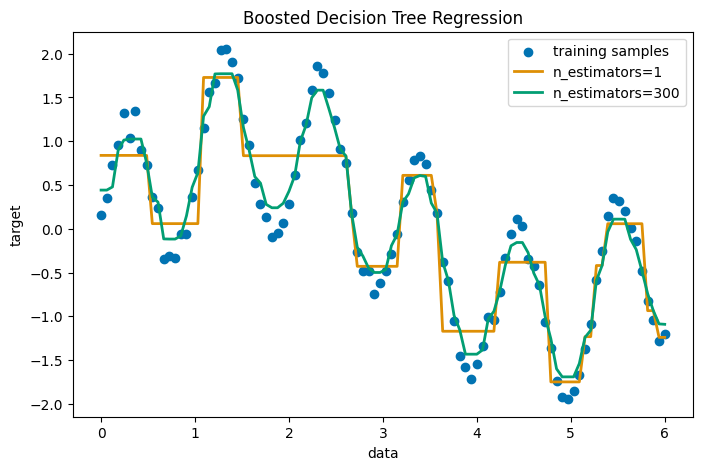

In [ ]:
colors = sns.color_palette("colorblind")

plt.figure(figsize=(8,5))
plt.scatter(X_boost, y_boost, color=colors[0], label="training samples")
plt.plot(X_boost, y_1, color=colors[1], label="n_estimators=1", linewidth=2)
plt.plot(X_boost, y_2, color=colors[2], label="n_estimators=300", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Boosted Decision Tree Regression")
plt.legend()
plt.show()

A Figura acima mostra as fronteiras de decisão de cinco preditores consecutivos. O primeiro classificador erra muitas instâncias, então seus pesos são aumentados. O segundo classificador faz um trabalho melhor nessas instâncias, e assim por diante.

Abaixo, um exemplo de **Regressão com AdaBoost**:

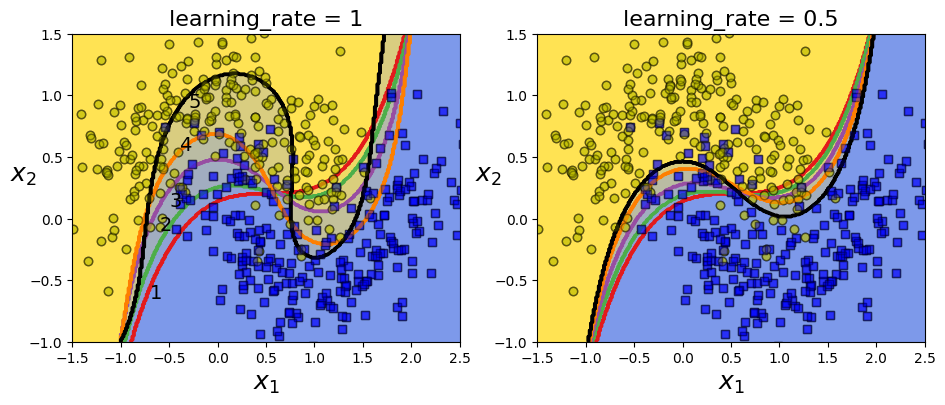

In [ ]:
ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=200, learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

m = len(X_train)
colors = ['#e41a1c', '#4daf4a', '#984ea3', '#ff7f00', '#000000']

plt.figure(figsize=(11, 4))
for subplot, learning_rate in ((121, 1), (122, 0.5)):
    sample_weights = np.ones(m)
    for i in range(5):
        plt.subplot(subplot)
        svm_clf = SVC(kernel="rbf", C=0.05)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights)
        y_pred = svm_clf.predict(X_train)
        sample_weights[y_pred != y_train] *= (1 + learning_rate)
        plot_decision_boundary(svm_clf, X, y, alpha=0.2, line_color=colors[i])
        plt.title(f"learning_rate = {learning_rate}", fontsize=16)

plt.subplot(121)
plt.text(-0.7, -0.65, "1", fontsize=14)
plt.text(-0.6, -0.10, "2", fontsize=14)
plt.text(-0.5,  0.10, "3", fontsize=14)
plt.text(-0.4,  0.55, "4", fontsize=14)
plt.text(-0.3,  0.90, "5", fontsize=14)
plt.show()

# 4. Stacking (Stacked Generalization)

O Stacking é uma arquitetura mais **heterogênea**. Em vez de funções triviais como votação, ele utiliza um **modelo de agregação (Meta-modelo ou Blender)**.

1. Vários modelos base diferentes (ex: RandomForest, Lasso, Gradient Boosting) fazem previsões.

2. As previsões desses modelos são usadas como **novos dados de entrada** para treinar um modelo final (Blender), que aprende qual a melhor forma de combinar as "opiniões".

**Treinamento Hold-out e Cascatas:**
Para evitar vazamento de dados, o conjunto de treino é dividido. A Camada 1 treina na Parte 1 e faz previsões "limpas" na Parte 2. A Parte 2 alimenta o Blender. O Stacking é escalável, permitindo múltiplas camadas!

In [ ]:
def load_ames_housing():
    df = fetch_openml(name="house_prices", as_frame=True)
    X = df.data
    y = df.target

    features = [
        "YrSold",
        "HeatingQC",
        "Street",
        "YearRemodAdd",
        "Heating",
        "MasVnrType",
        "BsmtUnfSF",
        "Foundation",
        "MasVnrArea",
        "MSSubClass",
        "ExterQual",
        "Condition2",
        "GarageCars",
        "GarageType",
        "OverallQual",
        "TotalBsmtSF",
        "BsmtFinSF1",
        "HouseStyle",
        "MiscFeature",
        "MoSold",
    ]

    X = X.loc[:, features]
    X, y = shuffle(X, y, random_state=0)

    X = X.iloc[:600]
    y = y.iloc[:600]
    return X, np.log(y)

In [ ]:
X, y = load_ames_housing()

X.head()

,YrSold,HeatingQC,Street,YearRemodAdd,Heating,MasVnrType,BsmtUnfSF,Foundation,MasVnrArea,MSSubClass,ExterQual,Condition2,GarageCars,GarageType,OverallQual,TotalBsmtSF,BsmtFinSF1,HouseStyle,MiscFeature,MoSold
529,2007,TA,Pave,1975,GasA,NaN,816,PConc,NaN,20,Gd,Norm,2,Attchd,6,2035,1219,1Story,NaN,3
491,2006,TA,Pave,1950,GasA,None,238,CBlock,0.0,50,TA,Norm,1,Attchd,6,806,403,1.5Fin,NaN,8
459,2009,TA,Pave,1950,GasA,BrkCmn,524,CBlock,161.0,50,TA,Norm,1,Detchd,5,709,185,1.5Fin,NaN,7
279,2008,Ex,Pave,1977,GasA,BrkFace,768,CBlock,299.0,60,TA,Norm,2,Attchd,7,1160,392,2Story,NaN,3
655,2010,TA,Pave,1971,GasA,BrkFace,525,CBlock,381.0,160,TA,Norm,1,Detchd,6,525,0,2Story,NaN,3


In [ ]:
cat_selector = make_column_selector(dtype_include=object)
num_selector = make_column_selector(dtype_include=np.number)

In [ ]:
# Processador para Árvores
cat_tree_processor = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-2)
num_tree_processor = SimpleImputer(strategy="mean", add_indicator=True)
tree_preprocessor = make_column_transformer((num_tree_processor, num_selector),
                                            (cat_tree_processor, cat_selector))

tree_preprocessor

ColumnTransformer(transformers=[('simpleimputer',
                                 SimpleImputer(add_indicator=True),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                ('ordinalencoder',
                                 OrdinalEncoder(encoded_missing_value=-2,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac07d0>)])

In [ ]:
# Processador Linear
cat_linear_processor = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
num_linear_processor = make_pipeline(StandardScaler(), SimpleImputer(strategy="mean", add_indicator=True))
linear_preprocessor = make_column_transformer((num_linear_processor, num_selector),
                                              (cat_linear_processor, cat_selector))

linear_preprocessor

ColumnTransformer(transformers=[('pipeline',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler()),
                                                 ('simpleimputer',
                                                  SimpleImputer(add_indicator=True))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac07d0>)])

In [ ]:
# Modelos Base
lasso_pipe = make_pipeline(linear_preprocessor, LassoCV())
lasso_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler()),
                                                                  ('simpleimputer',
                                                                   SimpleImputer(add_indicator=True))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac07d0>)])),
                ('lassocv', LassoCV())])

In [ ]:
rf_pipe = make_pipeline(tree_preprocessor, RandomForestRegressor(random_state=42))
rf_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('simpleimputer',
                                                  SimpleImputer(add_indicator=True),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(encoded_missing_value=-2,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac07d0>)])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
gbdt_pipe = make_pipeline(tree_preprocessor, HistGradientBoostingRegressor(random_state=0))
gbdt_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('simpleimputer',
                                                  SimpleImputer(add_indicator=True),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(encoded_missing_value=-2,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac07d0>)])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(random_state=0))])

In [ ]:
estimators = [
    ("Random Forest", rf_pipe),
    ("Lasso", lasso_pipe),
    ("Gradient Boosting", gbdt_pipe)
]

stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
stacking_regressor

StackingRegressor(estimators=[('Random Forest',
                               Pipeline(steps=[('columntransformer',
                                                ColumnTransformer(transformers=[('simpleimputer',
                                                                                 SimpleImputer(add_indicator=True),
                                                                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                                                                ('ordinalencoder',
                                                                                 OrdinalEncoder(encoded_missing_value=-2,
                                                                                                handle_unknown='use_encoded_value',
                                                                                                unknown_v...
                                                                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac0650>),
                                                                                ('ordinalencoder',
                                                                                 OrdinalEncoder(encoded_missing_value=-2,
                                                                                                handle_unknown='use_encoded_value',
                                                                                                unknown_value=-1),
                                                                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c24ccac07d0>)])),
                                               ('histgradientboostingregressor',
                                                HistGradientBoostingRegressor(random_state=0))]))],
                  final_estimator=RidgeCV())

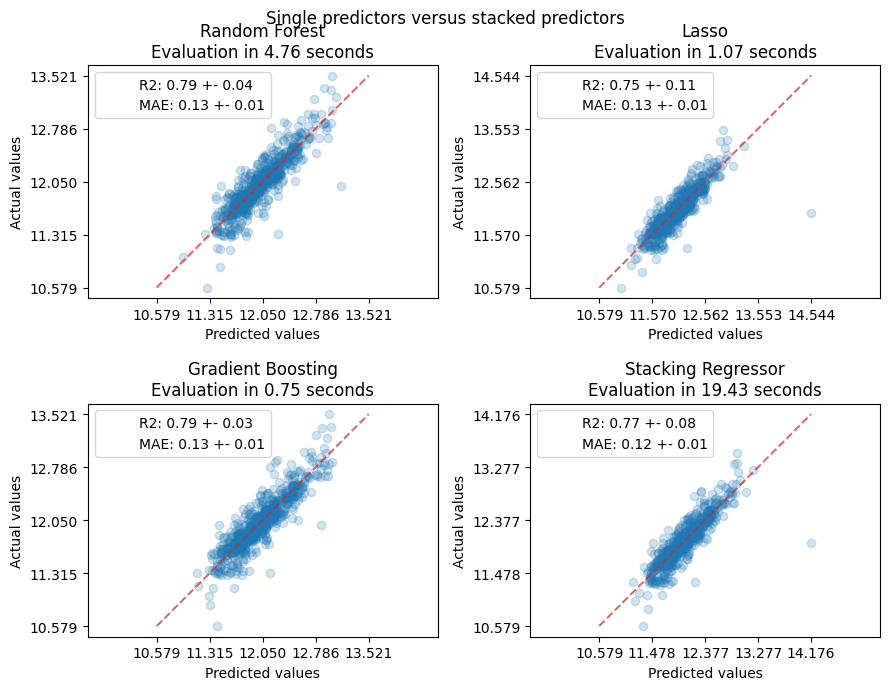

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
axs = np.ravel(axs)

for ax, (name, est) in zip(
    axs, estimators + [("Stacking Regressor", stacking_regressor)]
):
    scorers = {"R2": "r2", "MAE": "neg_mean_absolute_error"}

    start_time = time.time()
    scores = cross_validate(
        est, X, y, scoring=list(scorers.values()), n_jobs=-1, verbose=0
    )
    elapsed_time = time.time() - start_time

    y_pred = cross_val_predict(est, X, y, n_jobs=-1, verbose=0)
    scores = {
        key: (
            f"{np.abs(np.mean(scores[f'test_{value}'])):.2f} +- "
            f"{np.std(scores[f'test_{value}']):.2f}"
        )
        for key, value in scorers.items()
    }

    display = PredictionErrorDisplay.from_predictions(
        y_true=y,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
        line_kwargs={"color": "tab:red"},
    )
    ax.set_title(f"{name}\nEvaluation in {elapsed_time:.2f} seconds")

    for name, score in scores.items():
        ax.plot([], [], " ", label=f"{name}: {score}")
    ax.legend(loc="upper left")

plt.suptitle("Single predictors versus stacked predictors")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# 5. Resumo: As Famílias do Aprendizado Ensemble

Para consolidar o conhecimento, veja como as técnicas diferem na sua arquitetura principal:

| Característica | Bagging & Pasting | Boosting | Stacking |
| :--- | :--- | :--- | :--- |
| **Arquitetura** | Homogênea (mesmo modelo base) | Homogênea (mesmo modelo base) | Heterogênea (modelos diferentes) |
| **Treinamento** | **Paralelo** (Independentes) | **Sequencial** (Um corrige o outro) | **Camadas** (Independentes na base, hierárquicos depois) |
| **Objetivo Principal** | Reduzir a **Variância** (evitar overfitting) | Reduzir o **Viés** (transformar fracos em fortes) | Encontrar a **combinação ótima** de diferentes modelos |
| **Agregação Final** | Votação simples ou Média | Soma Ponderada (melhores têm mais peso) | **Meta-modelo** (Blender aprende a melhor combinação) |
| **Exemplos** | Random Forest | AdaBoost, Gradient Boosting (XGBoost) | N/A (Arquitetura customizada) |